In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("placement.csv")

In [5]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [7]:
df.tail()

,cgpa,package
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96
199,6.22,2.33


In [9]:
df.sample(5)

,cgpa,package
100,7.95,4.14
182,5.88,2.08
0,6.89,3.26
149,8.28,3.67
23,6.19,2.48


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [13]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [15]:
df.isnull().sum()

cgpa       0
package    0
dtype: int64

In [17]:
df.duplicated().sum()

0

In [19]:
df.nunique()

cgpa       163
package    138
dtype: int64

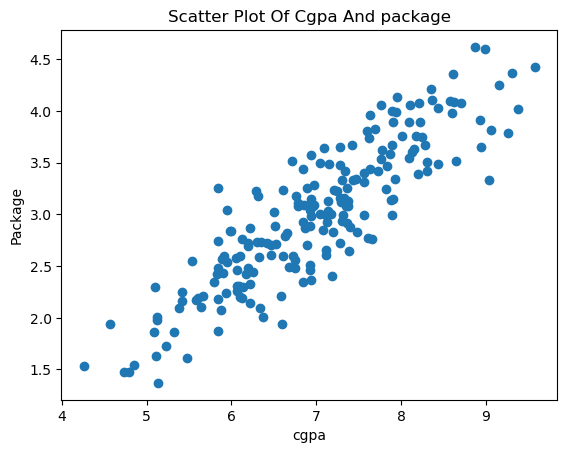

In [29]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("cgpa")
plt.ylabel("Package")
plt.title("Scatter Plot Of Cgpa And package")
plt.show()

In [31]:
X = df.iloc[:,:1]
y = df.iloc[:,-1]

In [37]:
from sklearn.model_selection import train_test_split


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [43]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))


MAE:  0.26487099179073786
MSE:  0.10350765119463193


In [59]:
import numpy as np

y_pred_class = np.round(y_pred)
y_test_class = np.round(y_test)
accuracy_score(y_test_class, y_pred_class)

0.7424242424242424

Text(0, 0.5, 'Package(in lpa)')

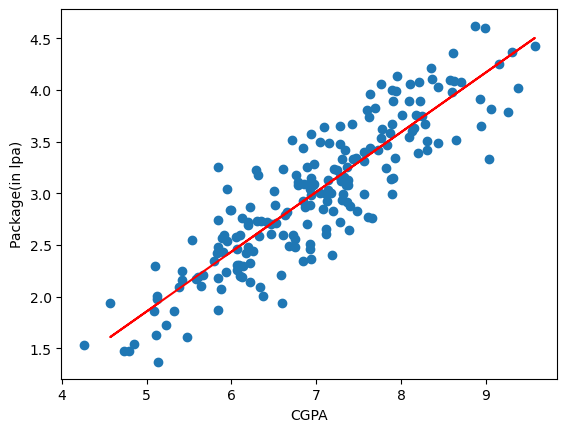

In [65]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')